# **Hadamard Transform**

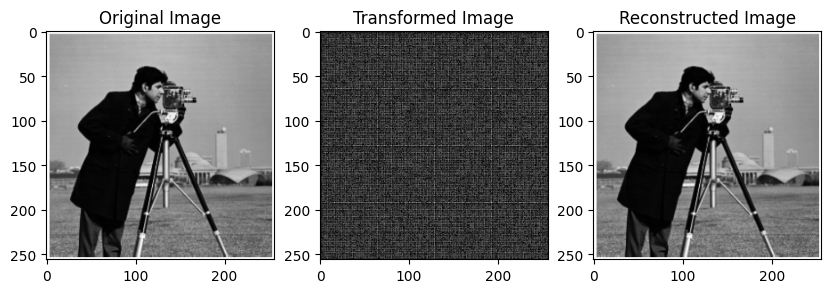

In [ ]:
import numpy as np
from scipy.linalg import hadamard
import cv2
import matplotlib.pyplot as plt

# Load an image and convert it to grayscale
image = cv2.imread("thr.png", cv2.IMREAD_GRAYSCALE)

# Resize the image to a power of 2 (e.g., 256x256) for Hadamard transform
image = cv2.resize(image, (256, 256))

# Display the original image
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

# Normalize the image to the range [0, 1]
image = image / 255.0

# Get the size of the image
n = image.shape[0]

# Generate the Hadamard matrix
H = hadamard(n)

# Apply the Hadamard transform
transformed_image = H @ image @ H

# Display the transformed image
plt.subplot(1, 3, 2)
plt.title("Transformed Image")
plt.imshow(np.log1p(np.abs(transformed_image)), cmap='gray')  # Log scale for visualization

# Apply the inverse Hadamard transform
reconstructed_image = (H @ transformed_image @ H) / (n * n)

# Display the reconstructed image
plt.subplot(1, 3, 3)
plt.title("Reconstructed Image")
plt.imshow(reconstructed_image, cmap='gray')

plt.show()

# **Practical Applications of Hadamard Transform**

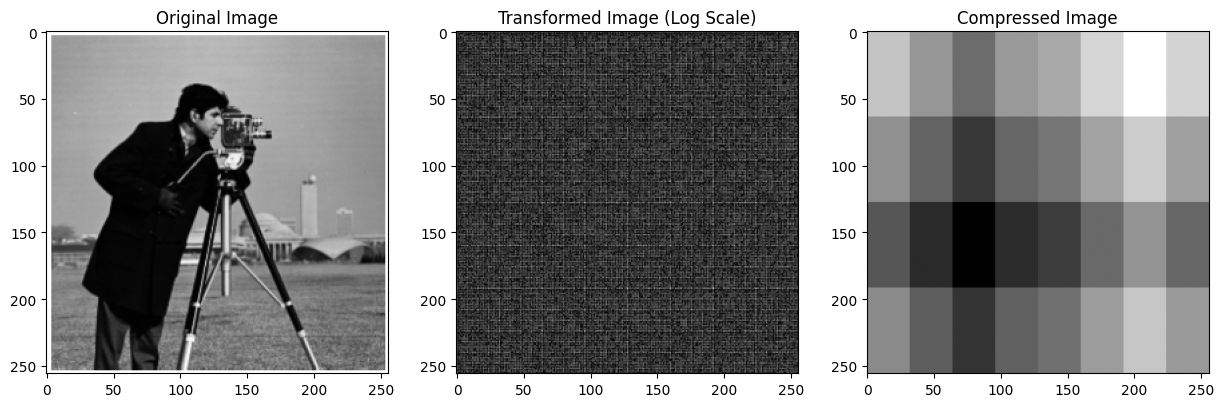

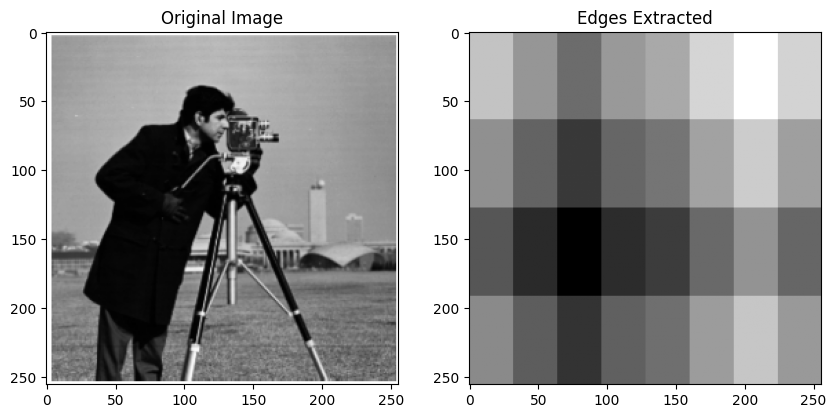

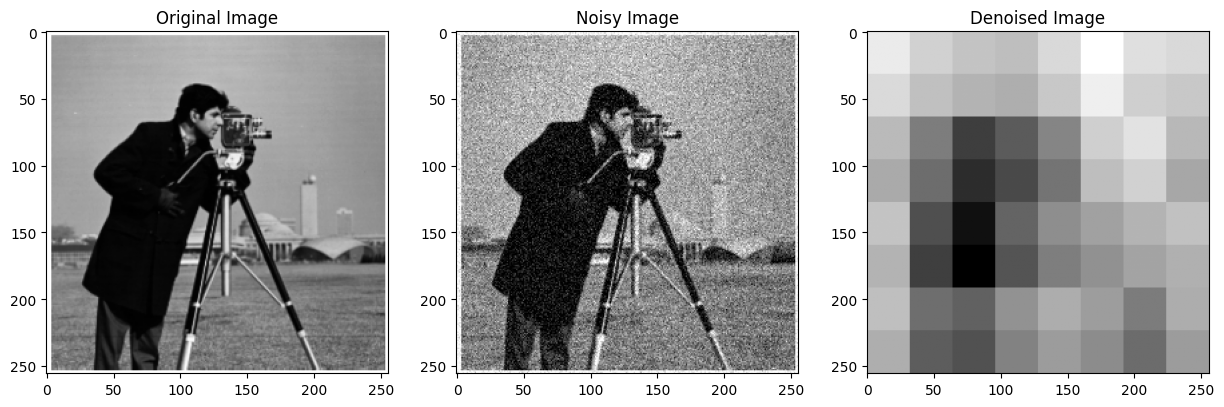

In [ ]:
import numpy as np
from scipy.linalg import hadamard
import cv2
import matplotlib.pyplot as plt

# Load an image and convert it to grayscale
image = cv2.imread("thr.png", cv2.IMREAD_GRAYSCALE)

# Resize the image to a power of 2 (e.g., 256x256) for Hadamard transform
image = cv2.resize(image, (256, 256))

# Normalize the image to the range [0, 1]
image = image / 255.0

# Get the size of the image
n = image.shape[0]

# Generate the Hadamard matrix
H = hadamard(n)

# Apply the Hadamard transform
transformed_image = H @ image @ H

# Display the original and transformed images
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Transformed Image (Log Scale)")
plt.imshow(np.log1p(np.abs(transformed_image)), cmap='gray')  # Log scale for visualization

# --- Practical Applications ---

# 1. Image Compression
# Set a threshold to discard small coefficients
threshold = 0.1 * np.max(np.abs(transformed_image))
compressed_transformed_image = np.where(np.abs(transformed_image) < threshold, 0, transformed_image)

# Reconstruct the compressed image
reconstructed_image = (H @ compressed_transformed_image @ H) / (n * n)

plt.subplot(1, 3, 3)
plt.title("Compressed Image")
plt.imshow(reconstructed_image, cmap='gray')

plt.show()

# 2. Feature Extraction (Edges)
# Extract edges by keeping only high-frequency components
high_freq_mask = np.abs(transformed_image) > 0.1 * np.max(np.abs(transformed_image))
edges_transformed_image = transformed_image * high_freq_mask

# Reconstruct the image with edges
edges_image = (H @ edges_transformed_image @ H) / (n * n)

# Normalize the edges image for better visualization
edges_image = np.clip(edges_image, 0, 1)  # Clip values to [0, 1]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Edges Extracted")
plt.imshow(edges_image, cmap='gray')

plt.show()

# 3. Noise Reduction
# Add random noise to the image
noise = np.random.normal(0, 0.1, image.shape)
noisy_image = image + noise

# Clip noisy image to [0, 1] range
noisy_image = np.clip(noisy_image, 0, 1)

# Apply Hadamard transform to the noisy image
noisy_transformed_image = H @ noisy_image @ H

# Threshold small coefficients to reduce noise
noise_threshold = 0.05 * np.max(np.abs(noisy_transformed_image))
denoised_transformed_image = np.where(np.abs(noisy_transformed_image) < noise_threshold, 0, noisy_transformed_image)

# Reconstruct the denoised image
denoised_image = (H @ denoised_transformed_image @ H) / (n * n)

# Clip denoised image to [0, 1] range
denoised_image = np.clip(denoised_image, 0, 1)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Noisy Image")
plt.imshow(noisy_image, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Denoised Image")
plt.imshow(denoised_image, cmap='gray')

plt.show()